# <a id='toc1_'></a>[<span style="color:yellow;">Segmentation: Otsu's Method</span>](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [<span style="color:yellow;">Segmentation: Otsu's Method</span>](#toc1_)    
- [Step 1: Import necessary libraries](#toc2_)    
- [Step 2: Load the built-in image](#toc3_)    
- [Step 3: Display the original image](#toc4_)    
- [Step 4: Compute and display the image histogram](#toc5_)    
- [Step 5: Calculate the optimal threshold using Otsu's method](#toc6_)    
- [Step 6: Apply the threshold to segment the image](#toc7_)    
- [Step 7: Display the segmentation result](#toc8_)    
- [Step 8: Visualize the effect of different thresholds](#toc9_)    
- [Step 9: Compute and visualize the between-class variance as a function of threshold](#toc10_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc2_'></a>[Step 1: Import necessary libraries](#toc0_)

In [74]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
from skimage import data
from skimage.filters import threshold_otsu
from skimage.color import rgb2gray
from skimage.util import img_as_ubyte

In [75]:
# Set seaborn style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [76]:
print("Libraries imported successfully. \nReady to perform image segmentation...")

Libraries imported successfully. 
Ready to perform image segmentation...


# <a id='toc3_'></a>[Step 2: Load the built-in image](#toc0_)

In [77]:
image = Image.open("hhh.jpg")
# 转化为灰度图
image = image.convert("L")
image = np.array(image)  # 转换为NumPy数组
print(f"Image loaded successfully.\nShape: {image.shape} ")

Image loaded successfully.
Shape: (4096, 3072) 


# <a id='toc4_'></a>[Step 3: Display the original image](#toc0_)

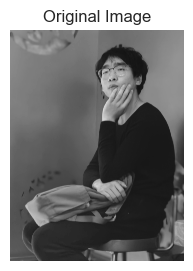

In [78]:
plt.figure(figsize=(4, 3))
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

In [79]:
print("Original image displayed. \nNext, 🧑‍💻 computing the histogram...")

Original image displayed. 
Next, 🧑‍💻 computing the histogram...


# <a id='toc5_'></a>[Step 4: Compute and display the image histogram](#toc0_)

An `image histogram` is a graphical/statistical tool that counts how many times each intensity value (e.g., brightness) appears in a digital image.<br><br>
It summarizes the distribution of pixel intensities, making it easy to analyze an image’s contrast, brightness, and tonal range.

* For `grayscale images`: Intensities typically range from 0 (black) to 255 (white). The histogram has 256 "bins" (one per intensity), where each bin’s height = number of pixels with that intensity.<br>
* For `color images`: Histograms are often calculated separately for each color channel (e.g., R, G, B in RGB images) to show intensity distribution per color.

Let an image have dimensions $M\times N$ (total pixels = $M\times N$), and let $I(x,y)$ = intensity value of the pixel at coordinates $(x,y)$ (where $x = 1,2,...,M; y = 1,2,...,N$).
The histogram $H(i)$ for intensity level $i$ is defined as: 
$$H(i) = \sum_{x=1}^{M} \sum_{y=1}^{N} \delta(I(x,y)-i)$$
Where $\delta(\cdot)$ is the `Kronecker delta function`.

In [80]:
hist, bins_center = np.histogram(image, bins=256)

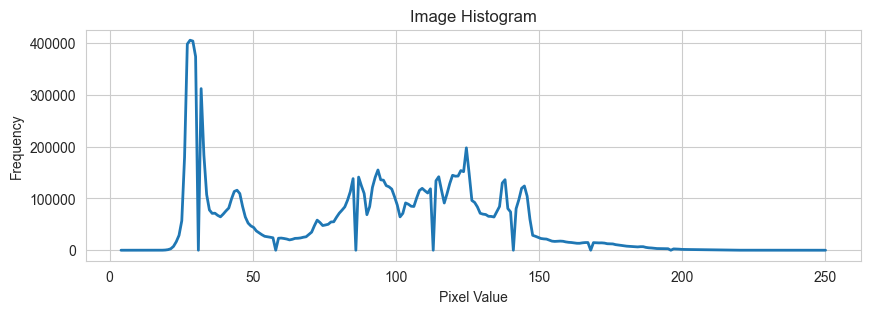

In [81]:
plt.figure(figsize=(10, 3))
plt.plot(bins_center[:-1], hist, lw=2)
plt.title('Image Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 直方图平滑处理

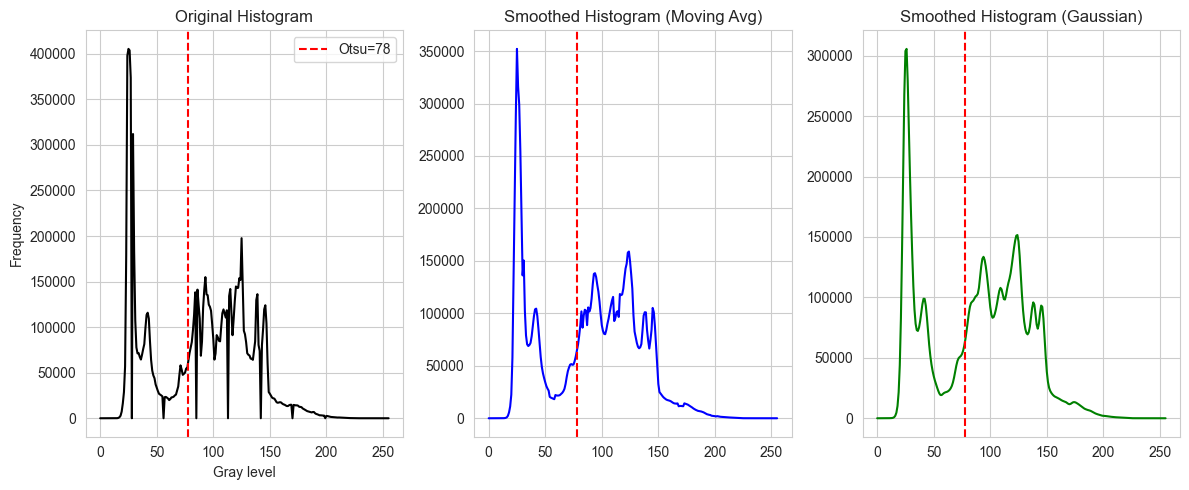

In [82]:

import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu


# 方法1：移动平均平滑
def moving_average(data, k=5):
    return np.convolve(data, np.ones(k)/k, mode='same')

hist_smooth = moving_average(hist, k=5)

# 方法2：高斯平滑（可选）
from scipy.ndimage import gaussian_filter1d
hist_gaussian = gaussian_filter1d(hist, sigma=2)

# Otsu 阈值
thresh_raw = threshold_otsu(image)

# 显示比较
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.plot(hist, color='black')
plt.axvline(thresh_raw, color='r', linestyle='--', label=f'Otsu={thresh_raw}')
plt.title("Original Histogram")
plt.xlabel("Gray level"), plt.ylabel("Frequency")
plt.legend()

plt.subplot(1,3,2)
plt.plot(hist_smooth, color='blue')
plt.axvline(thresh_raw, color='r', linestyle='--')
plt.title("Smoothed Histogram (Moving Avg)")

plt.subplot(1,3,3)
plt.plot(hist_gaussian, color='green')
plt.axvline(thresh_raw, color='r', linestyle='--')
plt.title("Smoothed Histogram (Gaussian)")

plt.tight_layout()
plt.show()


In [83]:
print("Image histogram displayed. \nNext, 🧮 calculating the threshold using Otsu's method...")

Image histogram displayed. 
Next, 🧮 calculating the threshold using Otsu's method...


# <a id='toc6_'></a>[Step 5: Calculate the optimal threshold using Otsu's method](#toc0_)

1. Look at the image’s gray levels: Make a histogram to know how many pixels are at each gray level (0–255).
1. Test every threshold: For each possible $T$ (0 to 255), calculate $\sigma_B^2$ (the `Between-Class Variance`).
1. Pick the best $T$: Choose the $T$ that makes $\sigma_B^2$ as large as possible. <br>
👋 That’s your optimal threshold!

In [84]:
thresh = threshold_otsu(image)
print(f"Optimal threshold calculated by Otsu's method: {thresh}")

Optimal threshold calculated by Otsu's method: 78


# <a id='toc7_'></a>[Step 6: Apply the threshold to segment the image](#toc0_)

In [85]:
binary = image > thresh

# <a id='toc8_'></a>[Step 7: Display the segmentation result](#toc0_)

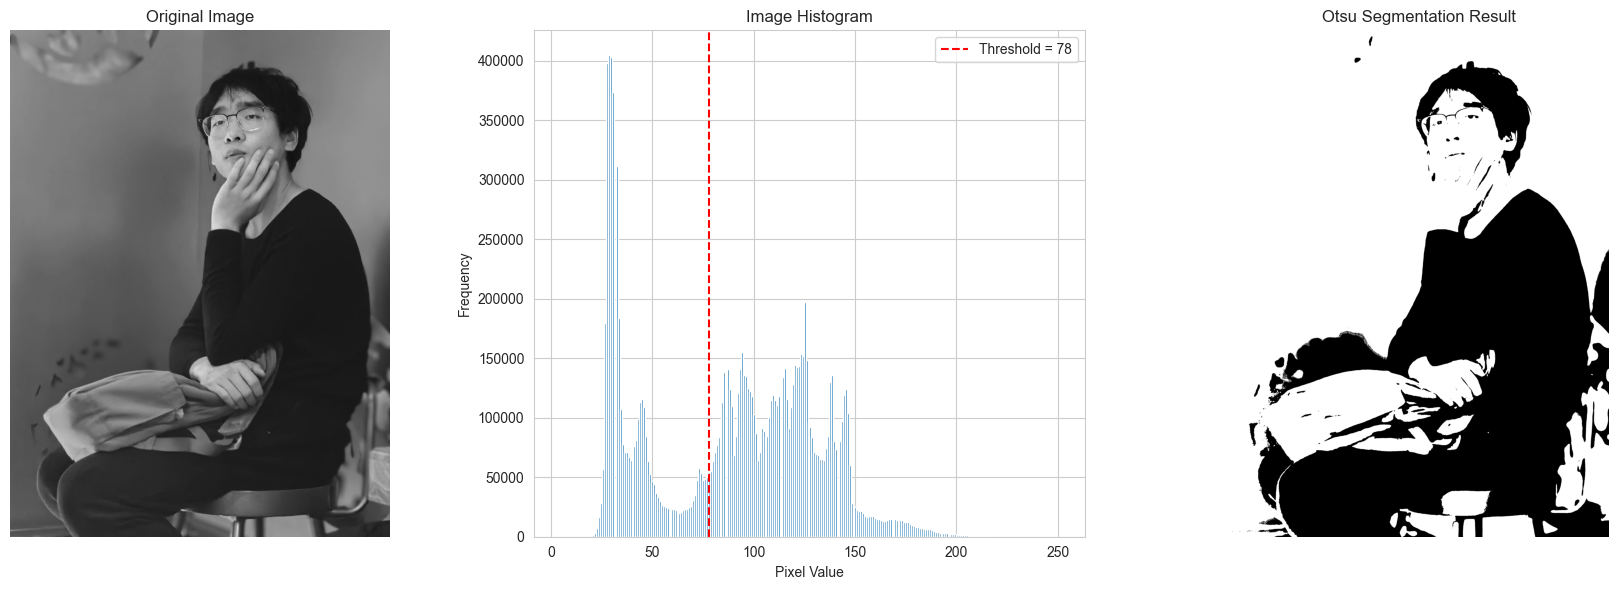

In [86]:
fig, axes = plt.subplots(ncols=3, figsize=(18, 6))
ax = axes.ravel()

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].hist(image.ravel(), bins=256)
ax[1].set_title('Image Histogram')
ax[1].axvline(thresh, color='r', linestyle='--', label=f'Threshold = {thresh}')
ax[1].legend()
ax[1].set_xlabel('Pixel Value')
ax[1].set_ylabel('Frequency')

ax[2].imshow(binary, cmap='gray')
ax[2].set_title('Otsu Segmentation Result')
ax[2].axis('off')

plt.tight_layout()
plt.show()

In [87]:
print("Otsu segmentation result displayed. \nNext, visualizing the effect of different thresholds...")

Otsu segmentation result displayed. 
Next, visualizing the effect of different thresholds...


# <a id='toc9_'></a>[Step 8: Visualize the effect of different thresholds](#toc0_)

In [88]:
thresholds = [50, 100, 150, thresh]  # Including Otsu's threshold

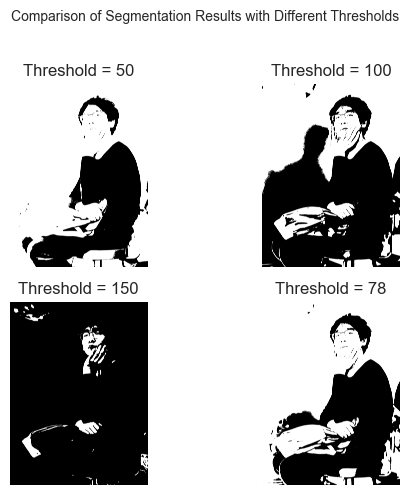

In [89]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(6, 5))
axes = axes.flatten()

for i, thresh_val in enumerate(thresholds):
    binary = image > thresh_val
    axes[i].imshow(binary, cmap='gray')
    axes[i].set_title(f'Threshold = {thresh_val}')
    axes[i].axis('off')

plt.suptitle('Comparison of Segmentation Results with Different Thresholds', fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [90]:
print("Comparison of different thresholds displayed. \nOtsu's method automatically selects the optimal threshold.")

Comparison of different thresholds displayed. 
Otsu's method automatically selects the optimal threshold.


# <a id='toc10_'></a>[Step 9: Compute and visualize the between-class variance as a function of threshold](#toc0_)

In [91]:
def compute_inter_class_variance(image):
    """Compute between-class variance for different thresholds"""
    pixel_counts = np.bincount(image.ravel())
    total_pixels = len(image.ravel())

    L = len(pixel_counts)  # 强度级数（最大像素值+1）

    sum_total = np.sum(np.arange(L) * pixel_counts)
    sumB = 0  # Sum of background pixels weighted by intensity
    wB = 0    # Number of background pixels
    var_max = 0
    threshold = 0
    
    variances = np.zeros(L)
    
    for t in range(L):
        wB += pixel_counts[t]
        if wB == 0:
            continue
        wF = total_pixels - wB
        if wF == 0:
            break
            
        sumB += t * pixel_counts[t]
        mB = sumB / wB
        mF = (sum_total - sumB) / wF
        
        var_between = wB * wF * (mB - mF) ** 2
        variances[t] = var_between
        
        if var_between > var_max:
            var_max = var_between
            threshold = t
            
    return variances, threshold

In [92]:
variances, _ = compute_inter_class_variance(img_as_ubyte(image))
print("First 5 variances:", variances[:5])  # Slices to get first 5 elements

First 5 variances: [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 9.01716106e+10]


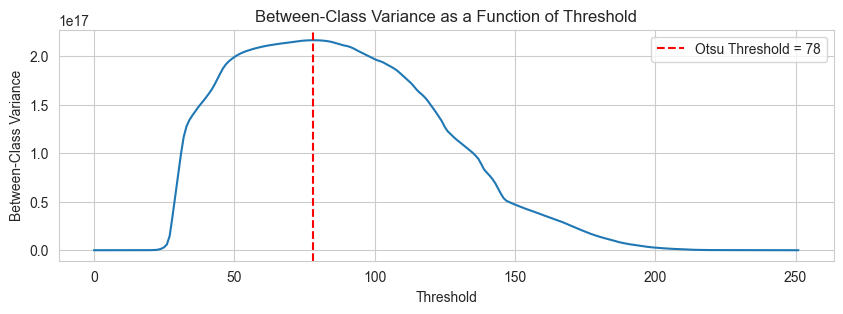

In [93]:
plt.figure(figsize=(10, 3))
plt.plot(variances)
plt.axvline(thresh, color='r', linestyle='--', label=f'Otsu Threshold = {thresh}')
plt.title('Between-Class Variance as a Function of Threshold')
plt.xlabel('Threshold')
plt.ylabel('Between-Class Variance')
plt.legend()
plt.grid(True)
plt.show()

In [94]:
print("Plot of between-class variance displayed. \nOtsu's method selects the threshold corresponding to the maximum variance.")    

Plot of between-class variance displayed. 
Otsu's method selects the threshold corresponding to the maximum variance.
